In [1]:
# =========================================================
# CELL 1: CÀI ĐẶT & IMPORT
# =========================================================
import subprocess, sys, os, gc, shutil, time

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    from ultralytics import YOLO
except ImportError:
    pip_install("ultralytics")
    from ultralytics import YOLO

import yaml
import numpy as np
import cv2
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
print(f"GPU count: {torch.cuda.device_count()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch  : 2.10.0+cu128
CUDA     : True
GPU count: 2


# 🔬 Experiment: Baseline vs Gamma-1.6 Training

So sánh 3 model trên cùng val set gốc:
- **baseline_no_aug** — model gốc đã train
- **with_copy_paste_03** — model copy-paste aug đã train
- **gamma_1.6_train** — **MỚI**: train from scratch trên data đã apply gamma=1.6

In [2]:
# =========================================================
# CELL 2: CẤU HÌNH ĐƯỜNG DẪN & GPU
# =========================================================
INPUT_ROOT = Path("/kaggle/input/competitions/3-lc-multi-vehicle-detection-challenge/competition_starter")
WORK_DIR   = Path("/kaggle/working")
DATA_DIR   = INPUT_ROOT / "data"

BASELINE_RUN_NAME = "baseline_no_aug_100ep"
BASELINE_WEIGHTS  = WORK_DIR / "runs" / BASELINE_RUN_NAME / "weights" / "best.pt"

if torch.cuda.device_count() >= 2:
    device_ids = [0, 1]
    print(f"✅ {torch.cuda.device_count()} GPU → chạy song song {device_ids}")
else:
    device_ids = 0 if torch.cuda.is_available() else "cpu"
    print(f"⚠️  GPU: {device_ids}")


✅ 2 GPU → chạy song song [0, 1]


# (Các bước build gamma dataset đã được bỏ — notebook này train baseline thuần)

# (Cell preview gamma — đã bỏ)

# (Cell build gamma dataset — đã bỏ)

# (Cell tạo gamma yaml — đã bỏ)

In [3]:
# =========================================================
# CELL 7: TRAIN BASELINE FROM SCRATCH (100 epochs)
# =========================================================
common_params = dict(
    epochs        = 100,
    imgsz         = 640,
    batch         = 128,
    lr0           = 0.01,
    lrf           = 0.01,
    momentum      = 0.937,
    weight_decay  = 0.0005,
    warmup_epochs = 3,
    close_mosaic  = 10,
    patience      = 0,
    project       = str(WORK_DIR / "runs"),
    pretrained    = False,
    exist_ok      = True,
    verbose       = True,
    workers       = 4,
    device        = device_ids,
    copy_paste    = 0.0,
)

# Dataset yaml gốc (không gamma)
ORIG_YAML = WORK_DIR / "dataset.yaml"
if not ORIG_YAML.exists():
    orig_cfg = {
        "train": str(DATA_DIR / "train" / "images"),
        "val"  : str(DATA_DIR / "val"   / "images"),
        "test" : str(DATA_DIR / "test"  / "images"),
        "nc"   : 4,
        "names": {0: "truck", 1: "car", 2: "van", 3: "bus"},
    }
    with open(ORIG_YAML, "w") as f:
        yaml.dump(orig_cfg, f, default_flow_style=False, sort_keys=False)
    print(f"✅ Đã tạo {ORIG_YAML}")

print(f"\n{'#'*60}")
print(f"🚀 BẮT ĐẦU TRAIN: {BASELINE_RUN_NAME.upper()}")
print(f"   Data: {ORIG_YAML}")
print(f"{'#'*60}\n")

model_baseline = YOLO("yolov8n.yaml")   # from scratch, không pretrained
model_baseline.train(data=str(ORIG_YAML), name=BASELINE_RUN_NAME, **common_params)

del model_baseline
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
time.sleep(5)

print(f"\n✅ Train xong! Weights: {BASELINE_WEIGHTS}")


✅ Đã tạo /kaggle/working/dataset.yaml

############################################################
🚀 BẮT ĐẦU TRAIN: BASELINE_NO_AUG_100EP
   Data: /kaggle/working/dataset.yaml
############################################################

Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hs

In [4]:
# =========================================================
# CELL 8: ĐỌC results.csv CỦA BASELINE
# =========================================================
MODELS = {
    BASELINE_RUN_NAME: {"weights": BASELINE_WEIGHTS, "color": "#2196F3", "label": "Baseline (100ep)"},
}

def load_results(run_name: str):
    p = WORK_DIR / "runs" / run_name / "results.csv"
    if not p.exists():
        print(f"  ⚠️  Không tìm thấy {p}")
        return None
    df = pd.read_csv(p)
    df.columns = df.columns.str.strip()
    df["run_name"] = run_name
    return df

results = {}
for rn in MODELS:
    df = load_results(rn)
    if df is not None:
        results[rn] = df
        print(f"✅ {rn}: {len(df)} epochs")

if results:
    print("\nCác cột:", list(results.values())[0].columns.tolist())


✅ baseline_no_aug_100ep: 100 epochs

Các cột: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'run_name']


/tmp/ipykernel_23/1752992178.py:41: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23/1752992178.py:42: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(WORK_DIR / "training_curves_comparison.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


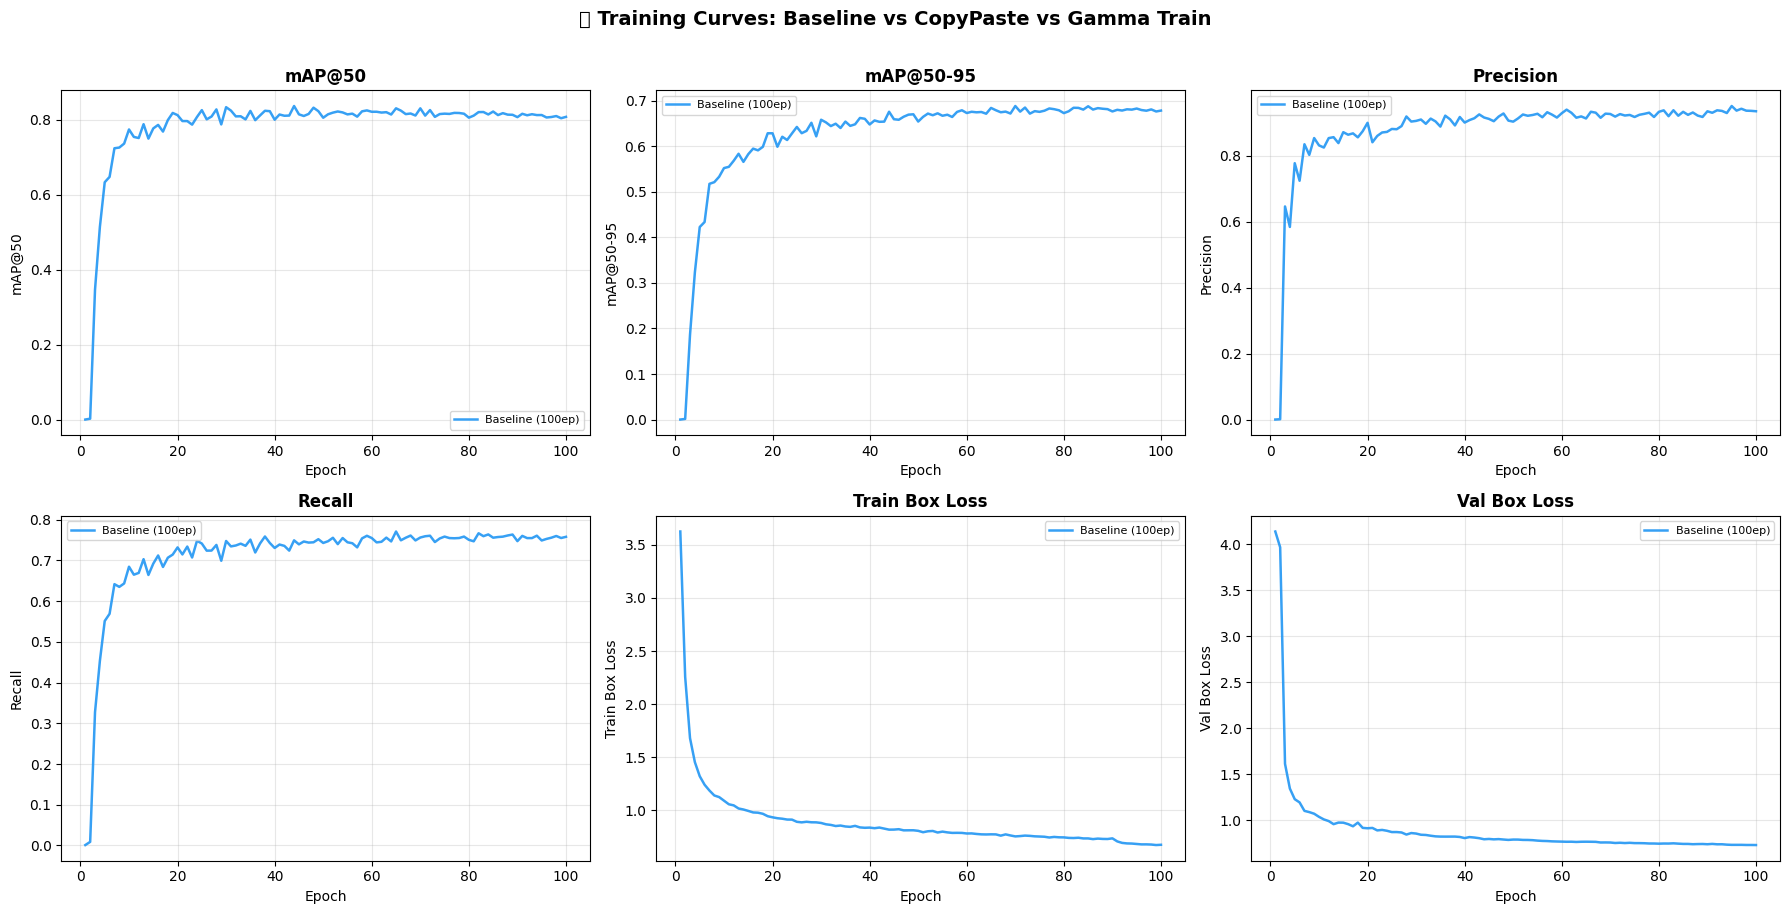

Đã lưu training_curves_comparison.png


In [5]:
# =========================================================
# CELL 9: TRAINING CURVES SO SÁNH
# =========================================================
METRIC_COLS = {
    "metrics/mAP50(B)"    : "mAP@50",
    "metrics/mAP50-95(B)" : "mAP@50-95",
    "metrics/precision(B)": "Precision",
    "metrics/recall(B)"   : "Recall",
    "train/box_loss"      : "Train Box Loss",
    "val/box_loss"        : "Val Box Loss",
}

available = {k: v for k, v in METRIC_COLS.items()
             if any(k in df.columns for df in results.values())}

ncols  = 3
nrows  = (len(available) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows))
axes = axes.flatten()

for idx, (col, label) in enumerate(available.items()):
    ax = axes[idx]
    for rn, df in results.items():
        if col not in df.columns:
            continue
        meta = MODELS[rn]
        epoch = df["epoch"] if "epoch" in df.columns else range(1, len(df) + 1)
        ax.plot(epoch, df[col], color=meta["color"], label=meta["label"],
                linewidth=1.8, alpha=0.9)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for i in range(len(available), len(axes)):
    axes[i].set_visible(False)

plt.suptitle("📊 Training Curves: Baseline vs CopyPaste vs Gamma Train",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(WORK_DIR / "training_curves_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Đã lưu training_curves_comparison.png")

In [6]:
# =========================================================
# CELL 10: VALIDATE BASELINE TRÊN VAL SET GỐC
# =========================================================
val_summary = []

for rn, meta in MODELS.items():
    w = meta["weights"]
    if not w.exists():
        print(f"⚠️  Bỏ qua {rn}: không thấy weights {w}")
        continue

    print(f"\n{'='*50}")
    print(f"🔍 Validating: {rn}")
    print(f"{'='*50}")

    m = YOLO(str(w))
    res = m.val(data=str(ORIG_YAML), imgsz=640, batch=64,
                device=device_ids, verbose=True, split="val")

    box = res.box
    val_summary.append({
        "Model"     : meta["label"],
        "run_name"  : rn,
        "mAP@50"    : round(float(box.map50), 4),
        "mAP@50-95" : round(float(box.map),   4),
        "Precision" : round(float(box.mp),     4),
        "Recall"    : round(float(box.mr),     4),
    })

    del m
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

summary_df = pd.DataFrame(val_summary).set_index("Model")
print("\n" + "="*60)
print("📋 KẾT QUẢ BASELINE 100EP (val set gốc)")
print("="*60)
print(summary_df.drop(columns=["run_name"]).to_string())



🔍 Validating: baseline_no_aug_100ep
Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 42.1±6.5 MB/s, size: 54.0 KB)
val: Scanning /kaggle/input/competitions/3-lc-multi-vehicle-detection-challenge/competition_starter/data/val/labels... 982 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 982/982 461.0it/s 2.1s
WARNING ⚠️ val: Cache directory /kaggle/input/competitions/3-lc-multi-vehicle-detection-challenge/competition_starter/data/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.5it/s 11.0s
                   all        982      11615      0.926      0.756       0.83      0.689
                 truck        185        207      0.932    

/tmp/ipykernel_23/3511858821.py:36: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23/3511858821.py:37: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(WORK_DIR / "comparison_bar_chart.png", dpi=120, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


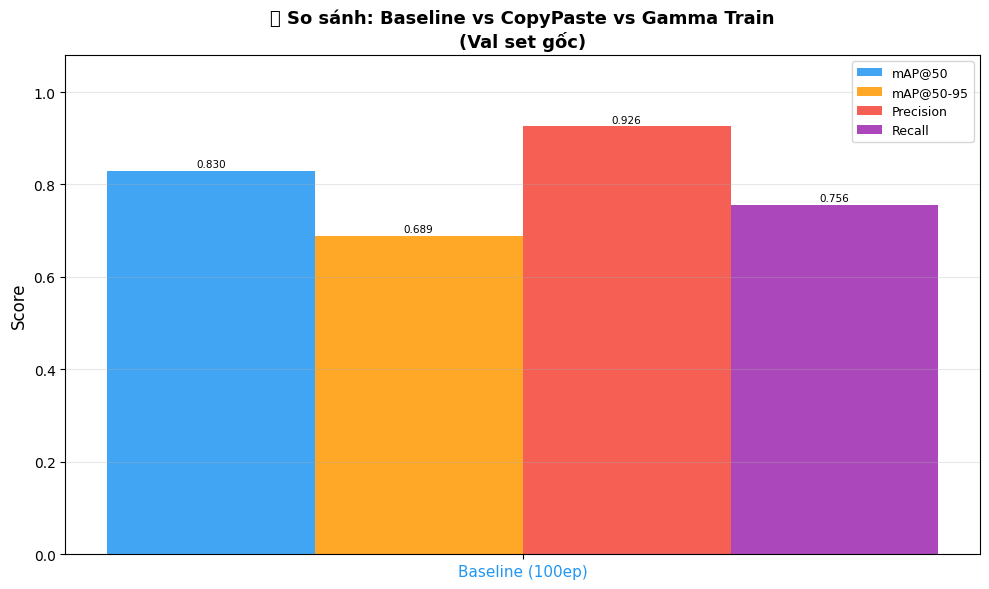

Đã lưu comparison_bar_chart.png


In [7]:
# =========================================================
# CELL 11: BAR CHART SO SÁNH
# =========================================================
metric_cols = ["mAP@50", "mAP@50-95", "Precision", "Recall"]
plot_df = summary_df[[c for c in metric_cols if c in summary_df.columns]]

x    = np.arange(len(plot_df))
bw   = 0.18
n_m  = len(plot_df.columns)
bar_colors = ["#2196F3", "#FF9800", "#F44336", "#9C27B0"]

fig, ax = plt.subplots(figsize=(max(10, 3 * len(plot_df)), 6))

for i, metric in enumerate(plot_df.columns):
    offset = (i - n_m / 2 + 0.5) * bw
    bars = ax.bar(x + offset, plot_df[metric], bw,
                  label=metric, color=bar_colors[i % len(bar_colors)], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.003,
                f"{h:.3f}", ha="center", va="bottom", fontsize=7.5)

model_colors = [MODELS[r]["color"] for r in summary_df["run_name"]]
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, fontsize=11)
for tick, color in zip(ax.get_xticklabels(), model_colors):
    tick.set_color(color)

ax.set_ylim(0, 1.08)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("📊 So sánh: Baseline vs CopyPaste vs Gamma Train\n(Val set gốc)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(WORK_DIR / "comparison_bar_chart.png", dpi=120, bbox_inches="tight")
plt.show()
print("Đã lưu comparison_bar_chart.png")

In [8]:
# =========================================================
# CELL 12: DELTA TABLE — SO VỚI BASELINE
# =========================================================
baseline_row = summary_df[summary_df["run_name"] == "baseline_no_aug"]

if baseline_row.empty:
    print("Không tìm thấy baseline để tính delta.")
else:
    delta_rows = []
    for _, row in summary_df.iterrows():
        if row["run_name"] == "baseline_no_aug":
            continue
        entry = {"Model": row.name}
        for m in metric_cols:
            if m in row.index:
                d = row[m] - baseline_row.iloc[0][m]
                entry[f"Δ {m}"] = f"{d:+.4f}"
        delta_rows.append(entry)

    delta_df = pd.DataFrame(delta_rows).set_index("Model")
    print("\n📈 DELTA SO VỚI BASELINE (+ = tốt hơn, − = kém hơn):")
    print(delta_df.to_string())

Không tìm thấy baseline để tính delta.
